# Analyse de données

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# syle et context taille de la police
sns.set_theme(style="whitegrid", context="notebook")
# 11x6 → bon ratio pour affichage écran / 16:9, meilleure lisibilité
plt.rcParams["figure.figsize"] = (11, 6)
robots = pd.read_csv('../data/robots_missions.csv')

In [19]:
robots.tail()

,timestamp,robot_id,robot_type,zone,task_type,mission_duration_s,downtime_s,battery_pct,speed_mps,temperature_c,error_code,mission_status,incident_label
5404,2026-02-11 20:00:00,R05,carrier,A2,inventory_scan,156,27,20.86,0.604,29.64,NaN,completed,0
5405,2026-02-11 20:00:00,R08,forklift,A1,inventory_scan,217,47,38.69,0.739,26.91,NaN,completed,0
5406,2026-02-06 15:20:00,R03,picker,C3,pick,-40,380,18.50,1.120,35.40,E_SENSOR_TEMP,failed,1
5407,2026-02-07 09:10:00,R11,picker,A2,inventory_scan,210,15,105.00,1.280,23.10,NaN,completed,0
5408,2026-02-07 09:10:00,R11,picker,A2,inventory_scan,210,15,105.00,1.280,23.10,NaN,completed,0


In [20]:
robots["timestamp"] = pd.to_datetime(robots["timestamp"], errors="coerce")

In [22]:
robots.info()

<class 'pandas.DataFrame'>
RangeIndex: 5409 entries, 0 to 5408
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           5409 non-null   datetime64[us]
 1   robot_id            5409 non-null   str           
 2   robot_type          5409 non-null   str           
 3   zone                5409 non-null   str           
 4   task_type           5409 non-null   str           
 5   mission_duration_s  5409 non-null   int64         
 6   downtime_s          5409 non-null   int64         
 7   battery_pct         5409 non-null   float64       
 8   speed_mps           5409 non-null   float64       
 9   temperature_c       5409 non-null   float64       
 10  error_code          247 non-null    str           
 11  mission_status      5409 non-null   str           
 12  incident_label      5409 non-null   int64         
dtypes: datetime64[us](1), float64(3), int64(3), str(6)
memory u

In [23]:
df = pd.DataFrame({
    "timestamp": ["2025-01-01", "invalid_date"]
})

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce") # NaT

print(df)
print(df.dtypes)


   timestamp
0 2025-01-01
1        NaT
timestamp    datetime64[us]
dtype: object


In [26]:
# Types numériques attendus
num_cols = ['mission_duration_s', 'downtime_s', 'battery_pct', 'speed_mps', 'temperature_c']
for c in num_cols:
    robots[c] = pd.to_numeric(robots[c], errors='coerce')
    print(robots[c])

0       174
1       179
2       219
3       242
4       187
       ... 
5404    156
5405    217
5406    -40
5407    210
5408    210
Name: mission_duration_s, Length: 5409, dtype: int64
0        18
1        19
2        13
3        27
4        31
       ... 
5404     27
5405     47
5406    380
5407     15
5408     15
Name: downtime_s, Length: 5409, dtype: int64
0        94.46
1        93.04
2        90.91
3        98.40
4        98.21
         ...  
5404     20.86
5405     38.69
5406     18.50
5407    105.00
5408    105.00
Name: battery_pct, Length: 5409, dtype: float64
0       1.081
1       1.197
2       1.257
3       1.537
4       1.082
        ...  
5404    0.604
5405    0.739
5406    1.120
5407    1.280
5408    1.280
Name: speed_mps, Length: 5409, dtype: float64
0       25.06
1       22.87
2       25.00
3       25.04
4       22.39
        ...  
5404    29.64
5405    26.91
5406    35.40
5407    23.10
5408    23.10
Name: temperature_c, Length: 5409, dtype: float64


In [28]:
robots["mission_duration_s"]>0

0        True
1        True
2        True
3        True
4        True
        ...  
5404     True
5405     True
5406    False
5407     True
5408     True
Name: mission_duration_s, Length: 5409, dtype: bool

In [29]:
(robots["mission_duration_s"]<0).sum()

np.int64(1)

In [31]:
robots[robots["mission_duration_s"]<0]

,timestamp,robot_id,robot_type,zone,task_type,mission_duration_s,downtime_s,battery_pct,speed_mps,temperature_c,error_code,mission_status,incident_label
5406,2026-02-06 15:20:00,R03,picker,C3,pick,-40,380,18.5,1.12,35.4,E_SENSOR_TEMP,failed,1


In [34]:
robots = robots[robots["battery_pct"].between(0, 100)]
robots["hour"] = robots["timestamp"].dt.hour
robots["day"] = robots["timestamp"].dt.date
robots["is_error"] = np.where(robots["error_code"].notna(), 1, 0)
robots["efficiency"] = robots["mission_duration_s"] / ( robots["downtime_s"] + robots["mission_duration_s"] )


In [35]:
robots.info()

<class 'pandas.DataFrame'>
RangeIndex: 5407 entries, 0 to 5406
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           5407 non-null   datetime64[us]
 1   robot_id            5407 non-null   str           
 2   robot_type          5407 non-null   str           
 3   zone                5407 non-null   str           
 4   task_type           5407 non-null   str           
 5   mission_duration_s  5407 non-null   int64         
 6   downtime_s          5407 non-null   int64         
 7   battery_pct         5407 non-null   float64       
 8   speed_mps           5407 non-null   float64       
 9   temperature_c       5407 non-null   float64       
 10  error_code          247 non-null    str           
 11  mission_status      5407 non-null   str           
 12  incident_label      5407 non-null   int64         
 13  hour                5407 non-null   int32         
 14  day

In [36]:
robots = robots.rename(columns={
    "timestamp": "event_ts",
    "robot_id" : "id",
    "robot_type": "type",
    "task_type": "task",
    "mission_duration_s": "duration",
    "downtime_s": "downtime",
    "battery_pct": "battery_level",
    "temperature_c": "temperature",
    "mission_status": "status",
    "incident_label": "incident",
    "error_code" : "error"
})


In [40]:
robots["is_error"] = np.where(robots["error"].notna(), 1, 0)

In [41]:
(np.where(robots["error"].notna(), 1, 0)).sum()

np.int64(247)

In [42]:
kpi_hour = robots.groupby("hour", as_index=False).agg(
    missions=("id", "count"),
    error_rate=("is_error", "mean"),
    avg_battery=("battery_level", "mean"),
)


In [43]:
kpi_hour

,hour,missions,error_rate,avg_battery
0,0,203,0.024631,100.000000
1,1,203,0.034483,100.000000
2,2,213,0.032864,99.988216
3,3,206,0.038835,99.938641
4,4,223,0.031390,99.482691
5,5,223,0.017937,98.402018
6,6,207,0.048309,97.043961
7,7,210,0.033333,94.066048
8,8,238,0.021008,90.548866
9,9,213,0.032864,87.012207


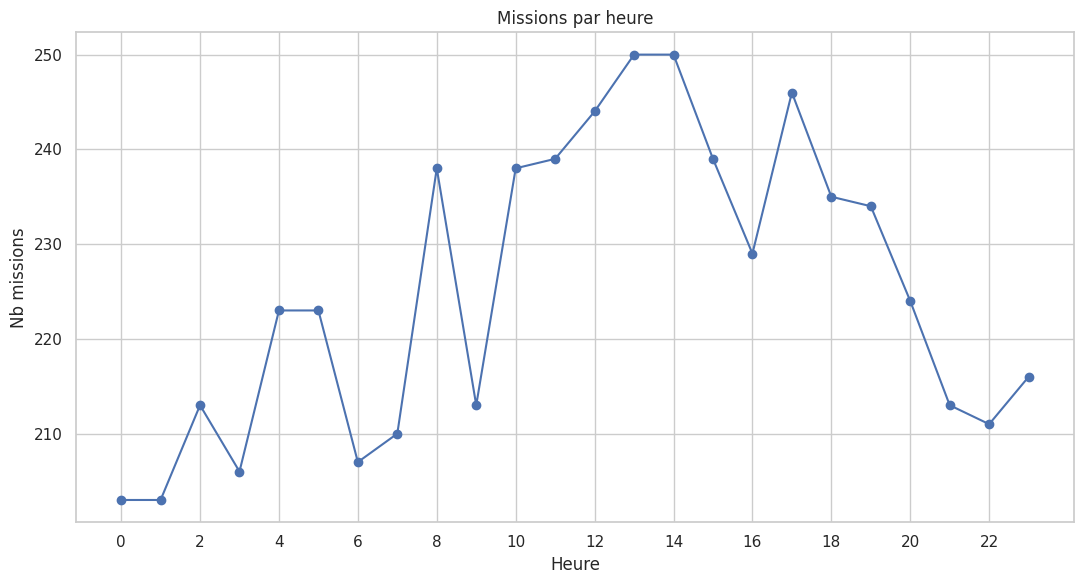

In [44]:
plt.plot(kpi_hour["hour"], kpi_hour["missions"], marker="o")
plt.title("Missions par heure")
plt.xlabel("Heure")
plt.ylabel("Nb missions")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()


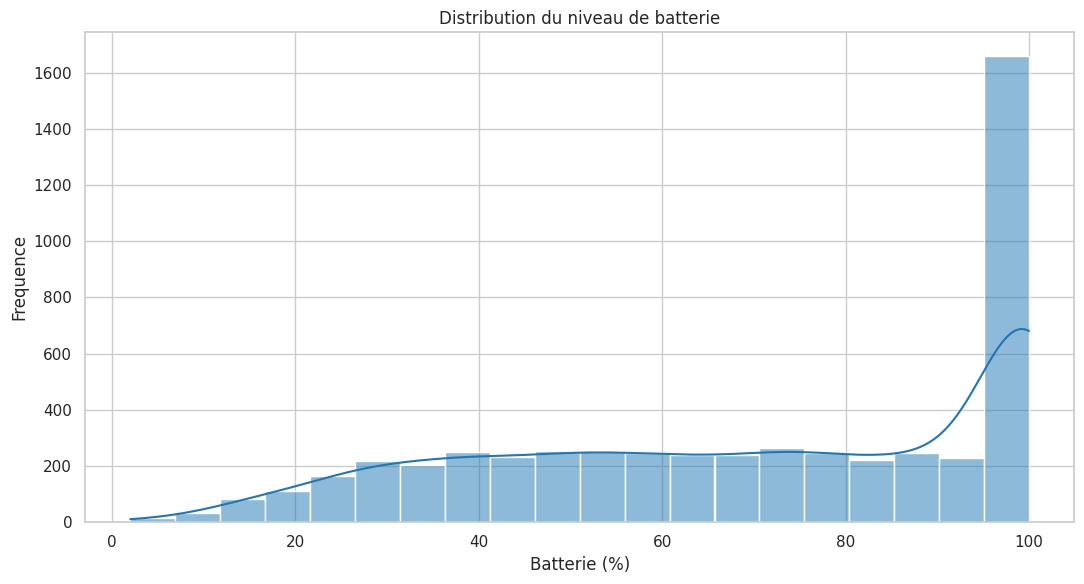

In [46]:
sns.histplot(robots, x="battery_level", bins=20, kde=True, color="#1f77b4")
plt.title("Distribution du niveau de batterie")
plt.xlabel("Batterie (%)")
plt.ylabel("Frequence")
plt.tight_layout()
plt.show()

In [47]:
robots["battery_bin"] = pd.cut(
    robots["battery_level"],
    bins=[0, 20, 50, 80, 100],
    labels=["0-20%", "20-50%", "50-80%", "80-100%"]
)


In [48]:
robots[["battery_bin", "id", "battery_level"]]

,battery_bin,id,battery_level
0,80-100%,R01,94.46
1,80-100%,R09,93.04
2,80-100%,R03,90.91
3,80-100%,R01,98.40
4,80-100%,R10,98.21
...,...,...,...
5402,20-50%,R11,30.01
5403,20-50%,R04,32.11
5404,20-50%,R05,20.86
5405,20-50%,R08,38.69


In [54]:
# error_by_battery = robots.groupby("battery_bin", as_index=False).agg(
#    is_error_mean=("is_error", "mean"),
#    battery_bin=("battery_bin", "cunt")
#)
#error_by_battery["is_error"]*=100

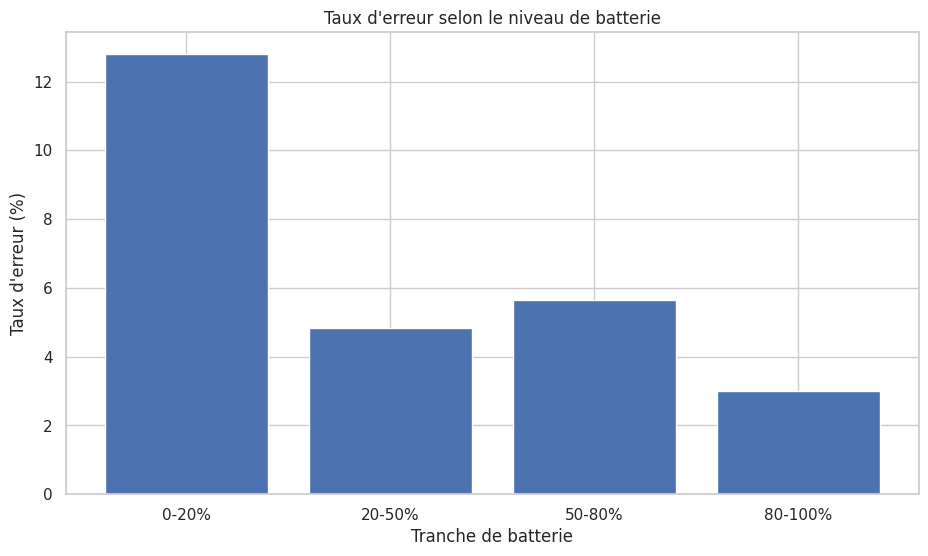

In [51]:
error_by_battery = robots.groupby("battery_bin", as_index=False).agg(
    is_error=("is_error", "mean"),
)

error_by_battery["is_error"] *= 100

plt.figure()
plt.bar(
    error_by_battery["battery_bin"].astype(str),
    error_by_battery["is_error"]
)
plt.xlabel("Tranche de batterie")
plt.ylabel("Taux d'erreur (%)")
plt.title("Taux d'erreur selon le niveau de batterie")
plt.show()


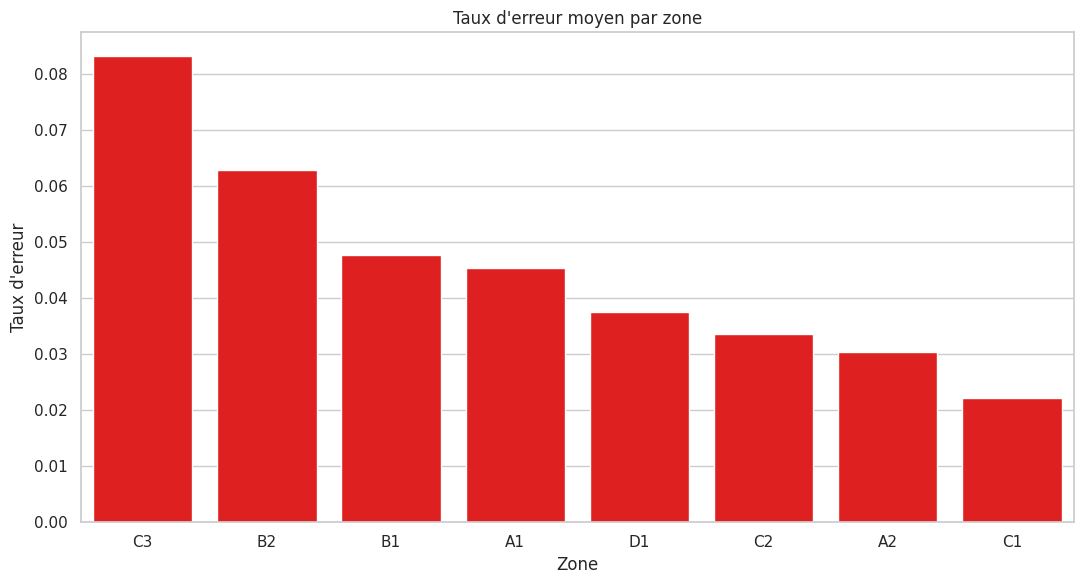

In [56]:
zone_err = robots.groupby("zone", as_index=False).agg(
    is_error = ("is_error", "mean")
).sort_values("is_error", ascending=False)

sns.barplot(data=zone_err, x="zone", y="is_error", color="red")
plt.title("Taux d'erreur moyen par zone")
plt.xlabel("Zone")
plt.ylabel("Taux d'erreur")
plt.tight_layout()
plt.show()


In [69]:
def upper_whisker(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1

    return q3 + 1.5 * iqr

s = pd.Series([10, 12, 13, 15, 18, 19, 20, 100])
# La fonction ".loc[]" permet de faire un masque croisé (selctionner une colonne en fonction de son contenu...)
r_loc = robots.loc[robots["type"] == "carrier", "downtime"]
r_loc

4       31
5        1
13      19
14       3
16      20
        ..
5393    22
5396    12
5398    10
5403    39
5404    27
Name: downtime, Length: 1814, dtype: int64

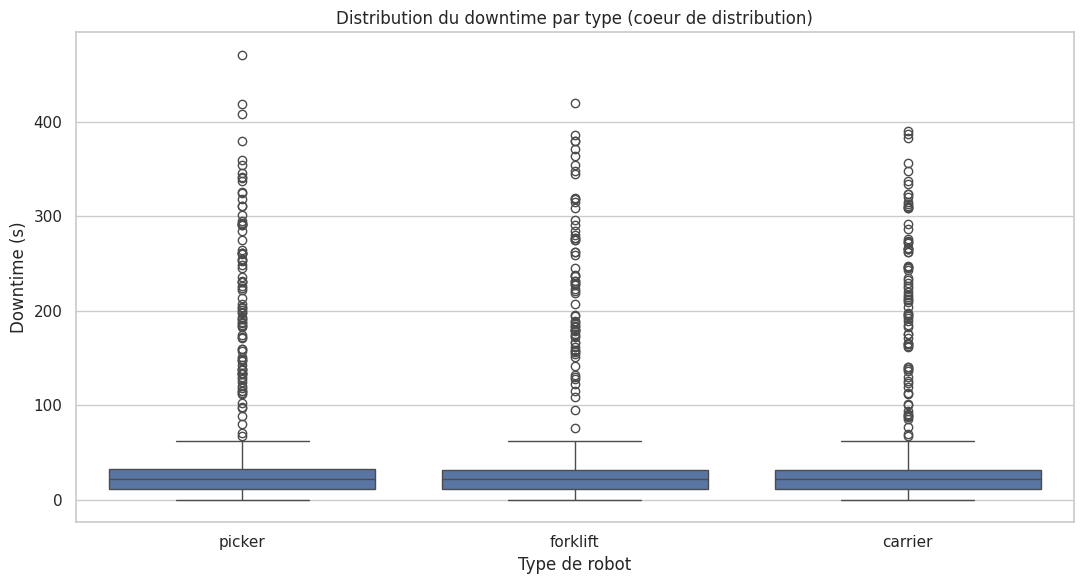

In [70]:
sns.boxplot(data=robots, x="type", y="downtime", showfliers=True)
plt.title("Distribution du downtime par type (coeur de distribution)")
plt.xlabel("Type de robot")
plt.ylabel("Downtime (s)")
plt.tight_layout()
plt.show()


In [81]:
def detect_outliers(col):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    borne_inf = q1-1.5*iqr
    

r_loc = robots.loc[robots["type"] == "carrier", "downtime"]
#r_loc
r_df = r_loc.to_frame(name="downtime")

sns.boxplot(y=r_df, showfliers=True)
plt.title("Distribution du downtime par type (coeur de distribution)")
plt.xlabel("Carrier")
plt.ylabel("Downtime (s)")
plt.tight_layout()
plt.show()


ValueError: If using all scalar values, you must pass an index